1. Author: Yuxuan Gou (Rebecca)
   Team: Yuxuan Gou and Shoshana Abikzer

2. This script focuses on exploratory data analysis (EDA) and visualization.
This code implements the analysis pipeline for the project.
It generates descriptive statistics and visualizations to examine the relationships among stress, sport facility density, and sleep quality.
Finally, a multivariate linear regression model is estimated to assess the effects of stress and sport facility density on sleep quality while controlling for individual and environmental factors.

3. AI DISCLOSURE
This project follows the course AI policy. Generative AI (ChatGPT, OpenAI) was used only for limited assistance with code refinement and project documentation.

Specifically, AI was used to:
- improve code comments and documentation for clarity
- check Python syntax and suggest minor debugging strategies
- refine wording for script descriptions and workflow explanations
- assist with organizing and describing the data processing pipeline

All core components of the analysis—including exploratory analysis, visualization, and statistical modeling—were written by the author.
AI was not used to generate first drafts of the code or to replace course learning objectives.

All AI use has been explicitly disclosed in accordance with the course policy.


In [ ]:
import pandas as pd

survey_matched = pd.read_csv(
    "/Users/rebecca/Downloads/30112/new data 2.16/Checkin2_Yuxuan Gou/Yuxuan Gou/Results/survey_matched.csv",
    encoding="utf-8-sig"
)

print(survey_matched.shape)
print(survey_matched.columns.tolist())

In [3]:
 
import pandas as pd

#### descriptive analysis
import numpy as np
import pandas as pd
"""
Generate descriptive statistics for the analytic dataset.

This code summarizes the main outcome and selected numeric predictors by computing 
sample size, missingness, mean, standard deviation, minimum, quartiles, median, 
and maximum. It also produces frequency tables for selected categorical variables, 
including counts and percentages for each category. The output tables are saved as 
CSV files for later use in reporting and analysis.
"""
df = survey_matched.copy()

y = "sleep_quality"
x_num = ["pss4_total", "facility_per_100k_pop", "age", "income_code", "edu_ord", "viirs_mean", "ndvi_mean"]
x_cat = ["gender", "hukou", "marital", "living_alone_3m"]

cols = [y] + x_num + x_cat
d = df[cols].copy()

for c in [y] + x_num:
    d[c] = pd.to_numeric(d[c], errors="coerce")

numeric_table = []
for c in [y] + x_num:
    s = d[c]
    numeric_table.append({
        "variable": c,
        "N": int(s.notna().sum()),
        "missing": int(s.isna().sum()),
        "missing_pct": float(s.isna().mean() * 100),
        "mean": float(s.mean(skipna=True)),
        "std": float(s.std(skipna=True, ddof=1)),
        "min": float(s.min(skipna=True)),
        "p25": float(s.quantile(0.25)),
        "median": float(s.quantile(0.50)),
        "p75": float(s.quantile(0.75)),
        "max": float(s.max(skipna=True)),
    })

numeric_table = pd.DataFrame(numeric_table)
#numeric_table.to_csv("descriptives_numeric.csv", index=False)

cat_rows = []
for c in x_cat:
    vc = d[c].astype("object").where(d[c].notna(), "NA").value_counts(dropna=False)
    total = vc.sum()
    for level, n in vc.items():
        cat_rows.append({
            "variable": c,
            "level": str(level),
            "count": int(n),
            "percent": float(n / total * 100),
        })

categorical_table = pd.DataFrame(cat_rows)
#categorical_table.to_csv("descriptives_categorical.csv", index=False)

print(numeric_table)
print(categorical_table.head(30))


print(list(survey_matched["viirs_mean"].value_counts(dropna = False)))





                variable     N  missing  missing_pct       mean        std  \
0          sleep_quality  1966        0          0.0  10.779756   2.663067   
1             pss4_total  1966        0          0.0   3.848932   3.687275   
2  facility_per_100k_pop  1966        0          0.0  50.584842  17.032472   
3                    age  1966        0          0.0  41.825025  15.102598   
4            income_code  1966        0          0.0   6.353510   2.315927   
5                edu_ord  1966        0          0.0   5.719736   1.872062   
6             viirs_mean  1966        0          0.0  46.031684  15.773424   
7              ndvi_mean  1966        0          0.0   0.437310   0.093088   

      min    p25  median     p75     max  
0   1.000   9.00  11.000  13.000  15.000  
1   0.000   1.00   3.000   6.000  16.000  
2  16.150  40.86  49.310  58.590  88.090  
3  20.000  30.00  38.000  52.000  92.000  
4   1.000   5.00   6.000   8.000  10.000  
5   1.000   4.00   6.000   7.000   9.00

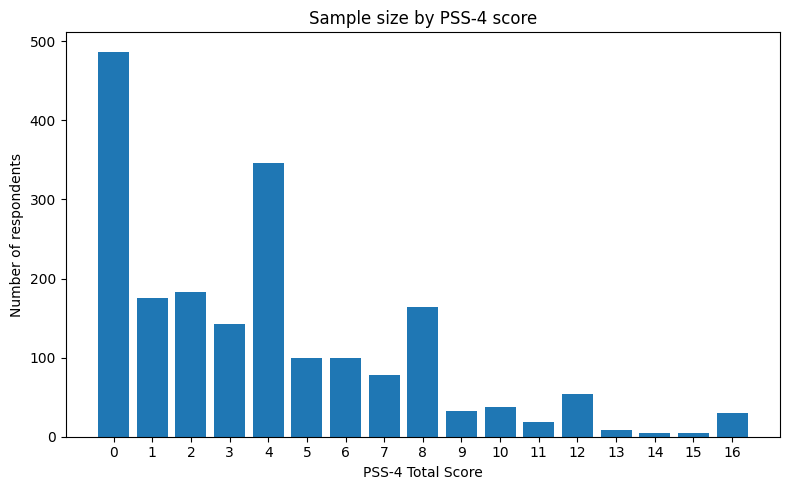

pss4_total
0     487
1     175
2     183
3     143
4     346
5      99
6      99
7      78
8     164
9      33
10     37
11     19
12     54
13      9
14      5
15      5
16     30
Name: count, dtype: int64


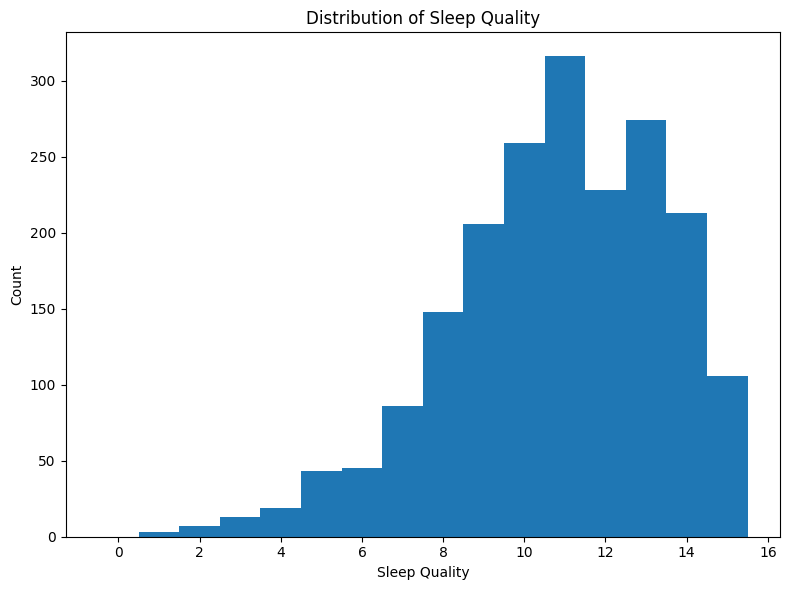

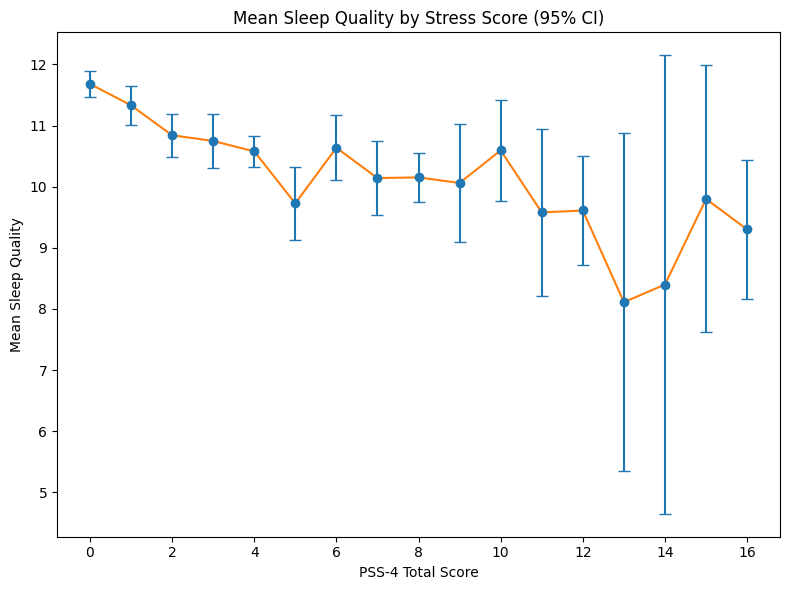

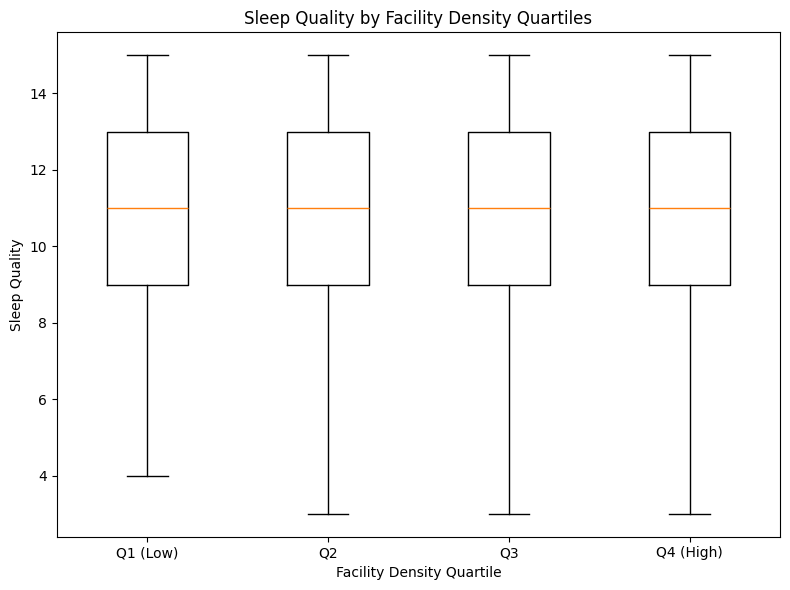

In [5]:
################## visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Convert key variables to numeric for plotting
survey_matched["sleep_quality"] = pd.to_numeric(survey_matched["sleep_quality"], errors="coerce")
survey_matched["pss4_total"] = pd.to_numeric(survey_matched["pss4_total"], errors="coerce")
survey_matched["facility_per_100k_pop"] = pd.to_numeric(survey_matched["facility_per_100k_pop"], errors="coerce")
## distribution of PSS-4 scores in the analytic sample
d = survey_matched[["pss4_total", "sleep_quality"]].copy()
d["pss4_total"] = pd.to_numeric(d["pss4_total"], errors="coerce")
d["sleep_quality"] = pd.to_numeric(d["sleep_quality"], errors="coerce")
d = d.dropna()

count_table = d["pss4_total"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(count_table.index, count_table.values)
plt.xlabel("PSS-4 Total Score")
plt.ylabel("Number of respondents")
plt.title("Sample size by PSS-4 score")
plt.xticks(count_table.index)
plt.tight_layout()
plt.show()

print(count_table)

# 1) Plot the distribution of sleep quality in the analytic sample
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
bins = np.arange(-0.5, 15.5 + 1, 1)
ax.hist(survey_matched["sleep_quality"].dropna(), bins=bins)
ax.set_title("Distribution of Sleep Quality")
ax.set_xlabel("Sleep Quality")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Plot mean sleep quality by stress score with 95% confidence intervals
d = survey_matched[["pss4_total", "sleep_quality"]].copy()
d["pss4_total"] = pd.to_numeric(d["pss4_total"], errors="coerce")
d["sleep_quality"] = pd.to_numeric(d["sleep_quality"], errors="coerce")
d = d.dropna()

g = d.groupby("pss4_total")["sleep_quality"].agg(["mean", "count", "std"]).reset_index()
g["se"] = g["std"] / np.sqrt(g["count"])
g["ci95"] = 1.96 * g["se"]

fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.errorbar(g["pss4_total"], g["mean"], yerr=g["ci95"], fmt="o", capsize=4)
ax.plot(g["pss4_total"], g["mean"])
ax.set_title("Mean Sleep Quality by Stress Score (95% CI)")
ax.set_xlabel("PSS-4 Total Score")
ax.set_ylabel("Mean Sleep Quality")
plt.tight_layout()
plt.show()

# 3) Plot sleep quality across quartiles of sport facility density
d3 = survey_matched[["facility_per_100k_pop", "sleep_quality"]].dropna().copy()
d3["facility_q"] = pd.qcut(
    d3["facility_per_100k_pop"],
    4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

labels = ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
groups = [d3.loc[d3["facility_q"] == lab, "sleep_quality"].to_numpy() for lab in labels]

fig = plt.figure(figsize=(8, 6))
ax = plt.gca()
ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.set_title("Sleep Quality by Facility Density Quartiles")
ax.set_xlabel("Facility Density Quartile")
ax.set_ylabel("Sleep Quality")
plt.tight_layout()
plt.show()



                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     40.07
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           3.96e-25
Time:                        11:45:32   Log-Likelihood:                -4656.3
No. Observations:                1966   AIC:                             9321.
Df Residuals:                    1962   BIC:                             9343.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

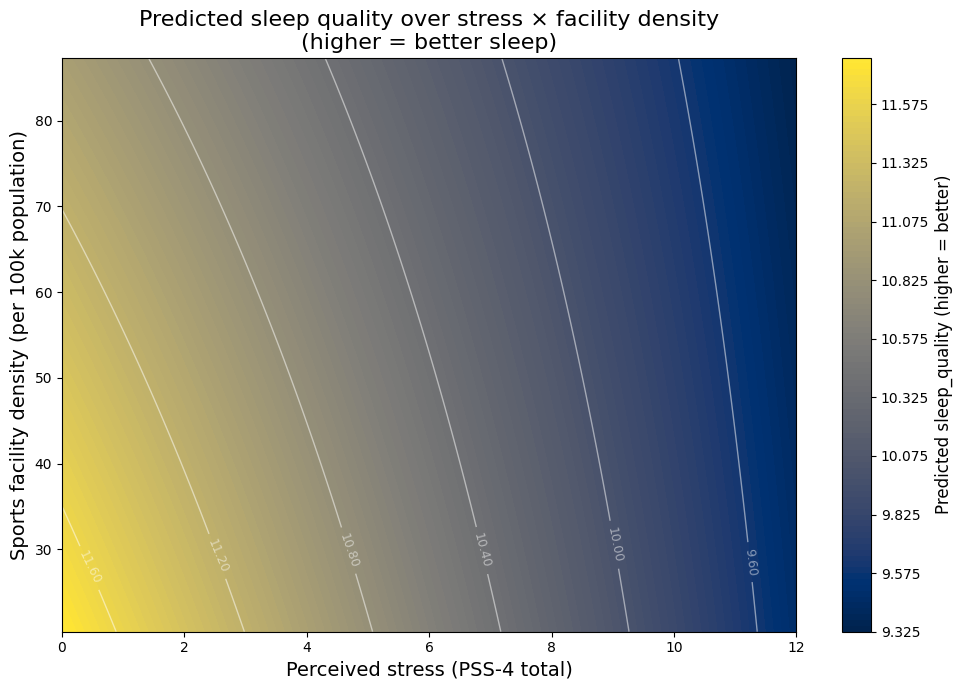

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# only keep the three variables
d = survey_matched[["sleep_quality", "pss4_total", "facility_per_100k_pop"]].copy()
d["sleep_quality"] = pd.to_numeric(d["sleep_quality"], errors="coerce")
d["pss4_total"] = pd.to_numeric(d["pss4_total"], errors="coerce")
d["facility_per_100k_pop"] = pd.to_numeric(d["facility_per_100k_pop"], errors="coerce")
d = d.dropna()

# fit interaction model
m_simple = smf.ols(
    "sleep_quality ~ pss4_total * facility_per_100k_pop",
    data=d
).fit()

print(m_simple.summary())

# build grid
stress_grid = np.linspace(d["pss4_total"].quantile(0.05), d["pss4_total"].quantile(0.95), 100)
facility_grid = np.linspace(d["facility_per_100k_pop"].quantile(0.05), d["facility_per_100k_pop"].quantile(0.05 if False else 0.95), 100)

S, F = np.meshgrid(stress_grid, facility_grid)

# prediction dataframe
pred_df = pd.DataFrame({
    "pss4_total": S.ravel(),
    "facility_per_100k_pop": F.ravel()
})

# predict sleep quality
Z = m_simple.predict(pred_df).to_numpy().reshape(S.shape)

# plot
plt.figure(figsize=(10, 7))

cf = plt.contourf(S, F, Z, levels=100, cmap="cividis")
cs = plt.contour(S, F, Z, colors="white", linewidths=1, alpha=0.5)
plt.clabel(cs, inline=True, fontsize=9, fmt="%.2f")

cbar = plt.colorbar(cf)
cbar.set_label("Predicted sleep_quality (higher = better)", fontsize=12)

plt.xlabel("Perceived stress (PSS-4 total)", fontsize=14)
plt.ylabel("Sports facility density (per 100k population)", fontsize=14)
plt.title(
    "Predicted sleep quality over stress × facility density\n"
    "(higher = better sleep)",
    fontsize=16
)

plt.tight_layout()
plt.show()

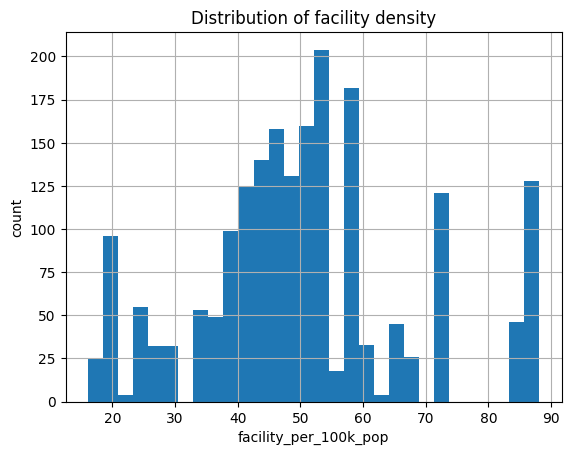

count    1966.000000
mean       50.584842
std        17.032472
min        16.150000
25%        40.860000
50%        49.310000
75%        58.590000
max        88.090000
Name: facility_per_100k_pop, dtype: float64
N = 1966
Pearson r = 0.066, p = 0.003182
Spearman rho = 0.055, p = 0.01437
                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     59.72
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           6.65e-26
Time:                        11:32:27   Log-Likelihood:                -4656.7
No. Observations:                1966   AIC:                             9319.
Df Residuals:                    1963   BIC:                             9336.
Df Model:                           2                                         
Co

In [ ]:

########### regression model

import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


# look at the distribution of facility density
survey_matched["facility_per_100k_pop"] = pd.to_numeric(
    survey_matched["facility_per_100k_pop"], errors="coerce"
)

survey_matched["facility_per_100k_pop"].hist(bins=30)
plt.title("Distribution of facility density")
plt.xlabel("facility_per_100k_pop")
plt.ylabel("count")
plt.show()

print(survey_matched["facility_per_100k_pop"].describe())


# check simple correlation between facility density and stress
d = survey_matched[["facility_per_100k_pop", "pss4_total"]].copy()
d["facility_per_100k_pop"] = pd.to_numeric(d["facility_per_100k_pop"], errors="coerce")
d["pss4_total"] = pd.to_numeric(d["pss4_total"], errors="coerce")
d = d.dropna()

x = d["facility_per_100k_pop"].to_numpy()
y = d["pss4_total"].to_numpy()

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"N = {len(d)}")
print(f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.4g}")
print(f"Spearman rho = {spearman_r:.3f}, p = {spearman_p:.4g}")


# model 1: only main predictors
m1 = smf.ols(
    "sleep_quality ~ pss4_total + facility_per_100k_pop",
    data=survey_matched
).fit()

print(m1.summary())




In [25]:
# model 2: add demographic and socioeconomic variables
m2 = smf.ols(
    "sleep_quality ~ pss4_total + facility_per_100k_pop "
    "+ age + C(gender) + C(hukou) + C(marital) + C(living_alone_3m) "
    "+ income_code + edu_ord",
    data=survey_matched
).fit()

print(m2.summary())



                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     16.78
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.37e-34
Time:                        11:33:16   Log-Likelihood:                -4618.3
No. Observations:                1966   AIC:                             9263.
Df Residuals:                    1953   BIC:                             9335.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [26]:

# model 3: add environmental variables
m3 = smf.ols(
    "sleep_quality ~ pss4_total + facility_per_100k_pop "
    "+ age + C(gender) + C(hukou) + C(marital) + C(living_alone_3m) "
    "+ income_code + edu_ord + viirs_mean + ndvi_mean",
    data=survey_matched
).fit()

print(m3.summary())



                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     14.39
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           2.01e-33
Time:                        11:33:26   Log-Likelihood:                -4618.2
No. Observations:                1966   AIC:                             9266.
Df Residuals:                    1951   BIC:                             9350.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [28]:
# model 4: only environmental variables
m_env = smf.ols(
    "sleep_quality ~ viirs_mean + ndvi_mean",
    data=survey_matched
).fit()

print("\nEnvironmental variables only")
print(m_env.summary())


Environmental variables only
                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.829
Date:                Sun, 08 Mar 2026   Prob (F-statistic):             0.0593
Time:                        11:35:47   Log-Likelihood:                -4712.0
No. Observations:                1966   AIC:                             9430.
Df Residuals:                    1963   BIC:                             9447.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.8686 

In [ ]:

# model 5: interaction between stress and facility density
m4 = smf.ols(
    "sleep_quality ~ pss4_total * facility_per_100k_pop "
    "+ age + C(gender) + C(hukou) + C(marital) + C(living_alone_3m) "
    "+ income_code + edu_ord + viirs_mean + ndvi_mean",
    data=survey_matched
).fit()

print(m4.summary())


                            OLS Regression Results                            
Dep. Variable:          sleep_quality   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     13.46
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           6.12e-33
Time:                        11:35:51   Log-Likelihood:                -4617.9
No. Observations:                1966   AIC:                             9268.
Df Residuals:                    1950   BIC:                             9357.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------